In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv("../data/taxi_trip_pricing.csv")

df.head()

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.59,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN
2,36.87,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.33,Evening,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698
4,NaN,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180


In [3]:
df = df.dropna(subset=["Trip_Price"])

In [4]:
X = df.drop(columns=["Trip_Price"])
y = df["Trip_Price"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [6]:
model = joblib.load("../models/linear_regression_pipeline.pkl")

In [7]:
type(model)

sklearn.pipeline.Pipeline

In [8]:
y_pred = model.predict(X_test)

In [9]:
residuals = y_test - y_pred

In [10]:
residuals.head()

210   -13.266597
445    -9.386535
730    18.240377
790     1.920678
533   -12.059414
Name: Trip_Price, dtype: float64

In [11]:
error_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred,
    "Residual": residuals
})

In [12]:
error_df["Absolute_Error"] = error_df["Residual"].abs()

In [13]:
error_df["Percentage_Error"] = error_df["Absolute_Error"] / error_df["Actual"].abs() * 100

In [14]:
error_df.head()

,Actual,Predicted,Residual,Absolute_Error,Percentage_Error
210,31.3844,44.650997,-13.266597,13.266597,42.271311
445,97.4848,106.871335,-9.386535,9.386535,9.628716
730,19.1069,0.866523,18.240377,18.240377,95.464870
790,47.1770,45.256322,1.920678,1.920678,4.071216
533,55.7598,67.819214,-12.059414,12.059414,21.627435


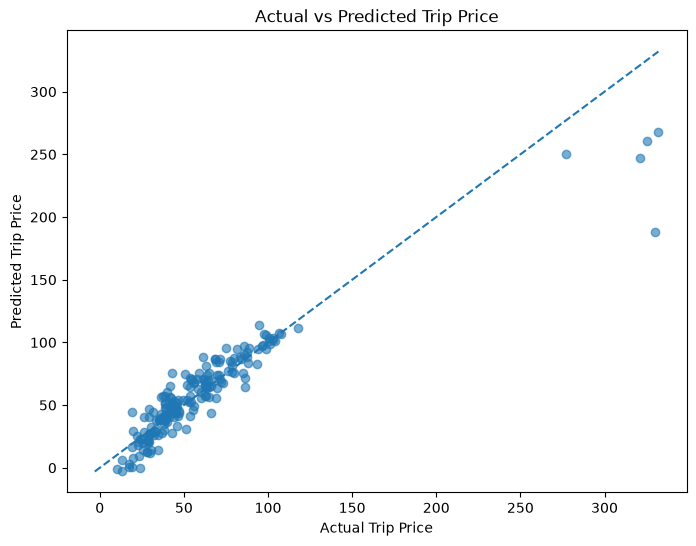

In [15]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

# Perfect prediction line
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Trip Price")
plt.ylabel("Predicted Trip Price")
plt.title("Actual vs Predicted Trip Price")

plt.show()

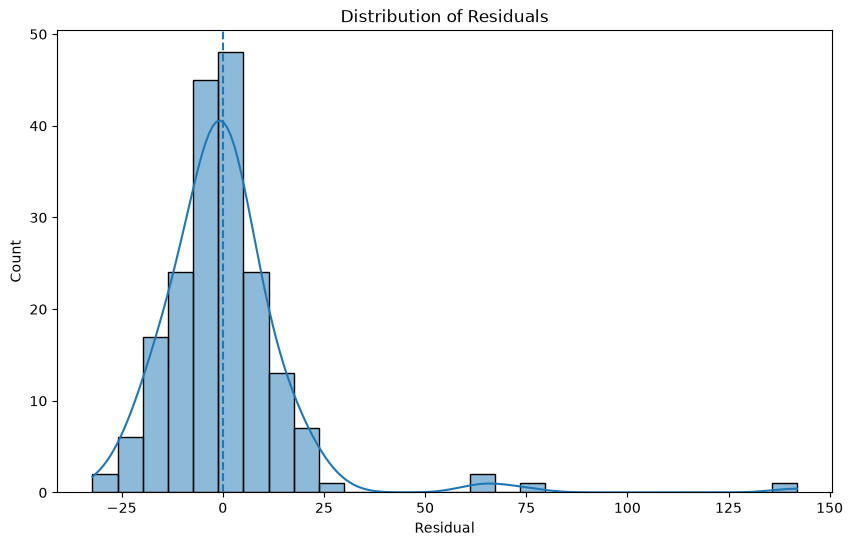

In [16]:
plt.figure(figsize=(10, 6))

sns.histplot(
    residuals,
    kde=True
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("Residual")
plt.title("Distribution of Residuals")

plt.show()

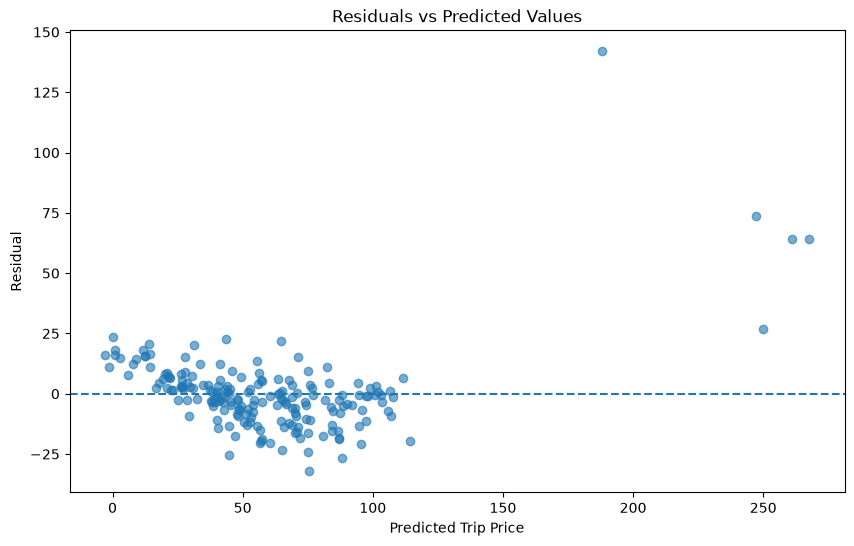

In [17]:
plt.figure(figsize=(10, 6))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Trip Price")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted Values")

plt.show()

In [18]:
error_analysis = X_test.copy()

error_analysis["Actual"] = y_test
error_analysis["Predicted"] = y_pred
error_analysis["Residual"] = residuals
error_analysis["Absolute_Error"] = residuals.abs()

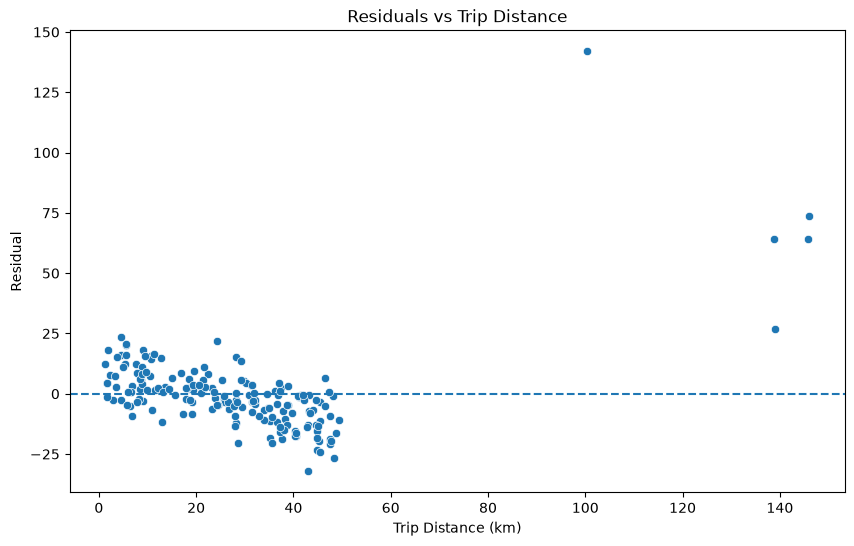

In [19]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=error_analysis,
    x="Trip_Distance_km",
    y="Residual"
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Trip Distance (km)")
plt.ylabel("Residual")
plt.title("Residuals vs Trip Distance")

plt.show()

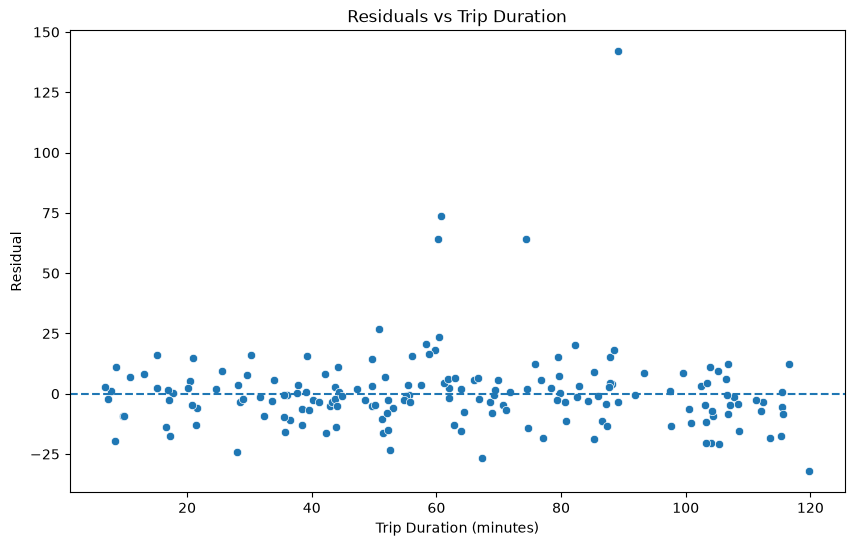

In [20]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=error_analysis,
    x="Trip_Duration_Minutes",
    y="Residual"
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Trip Duration (minutes)")
plt.ylabel("Residual")
plt.title("Residuals vs Trip Duration")

plt.show()

In [21]:
largest_errors = error_analysis.sort_values(by="Absolute_Error", ascending=False)

largest_errors.head(10)

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Actual,Predicted,Residual,Absolute_Error
287,100.380420,Afternoon,Weekday,3.0,Medium,Rain,4.46,NaN,NaN,89.21,329.913004,187.996521,141.916483,141.916483
64,146.067047,Afternoon,Weekday,2.0,Medium,Clear,4.79,0.73,0.30,60.81,320.958664,247.287926,73.670737,73.670737
616,138.763887,Night,Weekday,2.0,High,Clear,3.98,1.71,0.39,74.32,332.043689,267.734631,64.309058,64.309058
302,145.747060,Morning,Weekday,3.0,High,Rain,2.82,0.83,0.49,60.29,325.098950,260.996298,64.102652,64.102652
891,42.930000,Afternoon,Weekday,2.0,Medium,Clear,3.24,0.54,0.14,119.84,43.199800,75.434237,-32.234437,32.234437
268,139.062230,Afternoon,Weekday,2.0,Low,Rain,2.80,1.82,0.14,50.83,276.840597,249.946983,26.893613,26.893613
34,48.320000,Morning,Weekday,2.0,Low,Clear,2.49,0.61,0.44,67.25,61.555200,88.119143,-26.563943,26.563943
770,NaN,Afternoon,Weekday,1.0,Medium,Clear,3.05,0.98,0.24,NaN,19.090400,44.601519,-25.511119,25.511119
748,45.420000,Evening,Weekend,3.0,Medium,Clear,4.16,0.74,0.47,27.93,50.897900,74.992377,-24.094477,24.094477
354,4.460000,Afternoon,Weekend,3.0,Medium,Clear,3.22,0.53,0.30,60.41,23.706800,0.180572,23.526228,23.526228


In [22]:
largest_errors.iloc[0]

Trip_Distance_km          100.38042
Time_of_Day               Afternoon
Day_of_Week                 Weekday
Passenger_Count                 3.0
Traffic_Conditions           Medium
Weather                        Rain
Base_Fare                      4.46
Per_Km_Rate                     NaN
Per_Minute_Rate                 NaN
Trip_Duration_Minutes         89.21
Actual                   329.913004
Predicted                187.996521
Residual                 141.916483
Absolute_Error           141.916483
Name: 287, dtype: object

In [23]:
underpredictions = error_analysis[error_analysis["Residual"] > 0]

In [24]:
overpredictions = error_analysis[error_analysis["Residual"] < 0]

In [25]:
print("Underpredictions:", len(underpredictions))
print("Overpredictions:", len(overpredictions))

Underpredictions: 88
Overpredictions: 103


In [26]:
print("Mean residual:", residuals.mean())

Mean residual: 0.32770112056186596


In [27]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 9.930364474930709
MSE : 289.984447089814
RMSE: 17.028929710636955
R²  : 0.8759360526988045


In [28]:
error_analysis["Distance_Group"] = pd.cut(
    error_analysis["Trip_Distance_km"],
    bins=[0, 5, 10, 20, np.inf],
    labels=["0-5 km", "5-10 km", "10-20 km", "20+ km"]
)

In [29]:
distance_error = error_analysis.groupby("Distance_Group", observed=True)["Absolute_Error"].mean()

distance_error

Distance_Group
0-5 km       9.235859
5-10 km      8.177133
10-20 km     6.006557
20+ km      11.170990
Name: Absolute_Error, dtype: float64

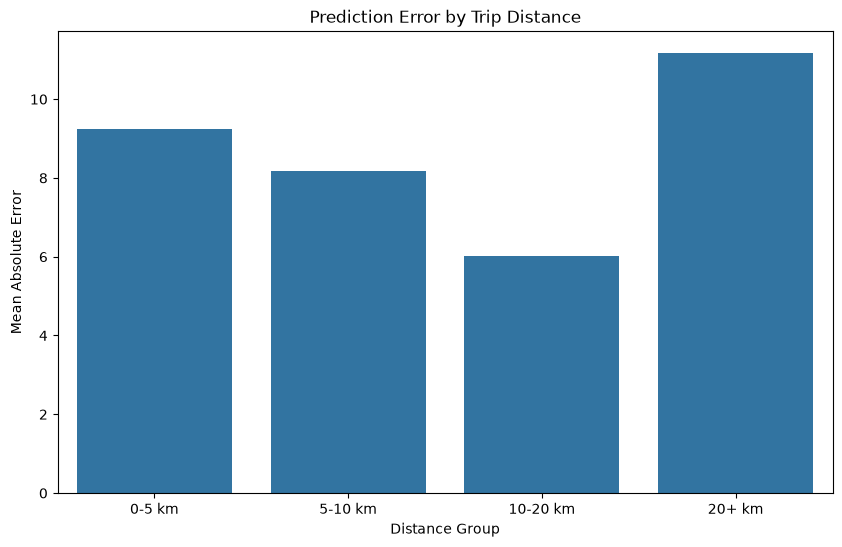

In [30]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=distance_error.index,
    y=distance_error.values
)

plt.xlabel("Distance Group")
plt.ylabel("Mean Absolute Error")
plt.title("Prediction Error by Trip Distance")

plt.show()

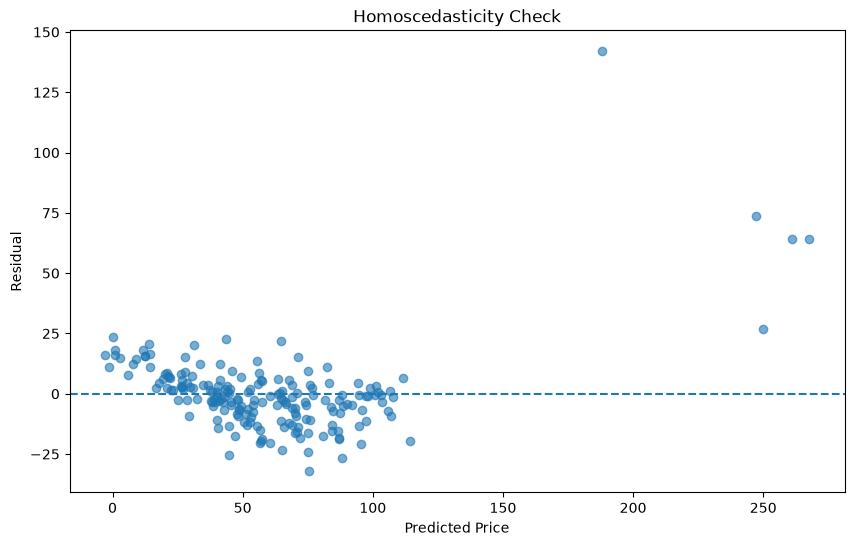

In [31]:
plt.figure(figsize=(10, 6))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.6
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Homoscedasticity Check")

plt.show()

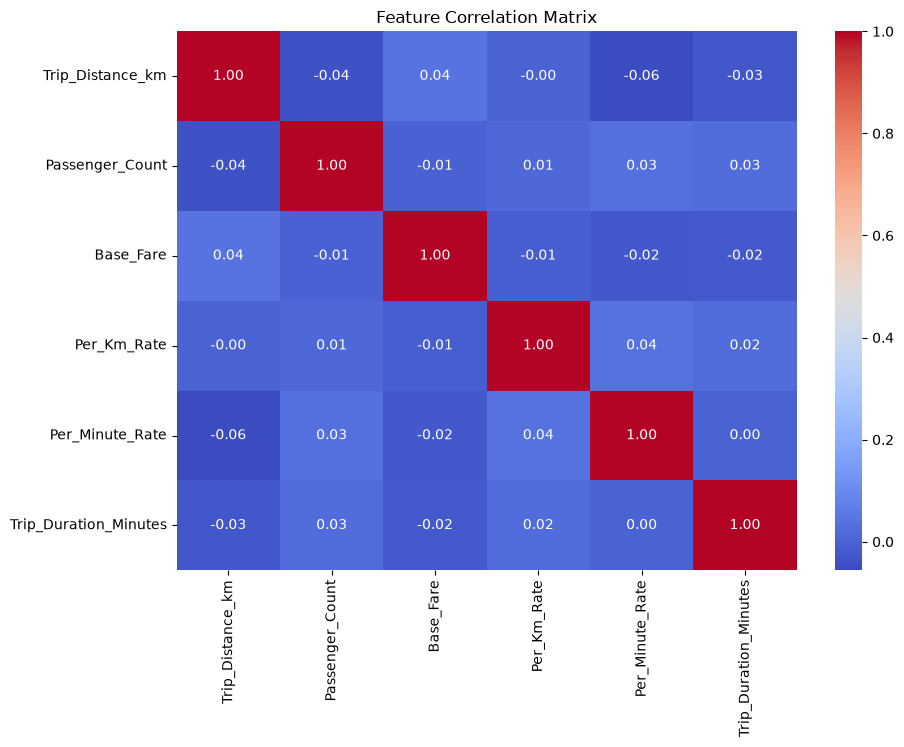

In [32]:
numeric_data = X_train.select_dtypes(
    include=np.number
)

plt.figure(figsize=(10, 7))

sns.heatmap(
    numeric_data.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Feature Correlation Matrix")

plt.show()

In [33]:
error_summary = pd.DataFrame({
    "Metric": [
        "MAE",
        "MSE",
        "RMSE",
        "R2",
        "Mean Residual",
        "Max Absolute Error"
    ],
    "Value": [
        mae,
        mse,
        rmse,
        r2,
        residuals.mean(),
        residuals.abs().max()
    ]
})

error_summary

,Metric,Value
0,MAE,9.930364
1,MSE,289.984447
2,RMSE,17.028930
3,R2,0.875936
4,Mean Residual,0.327701
5,Max Absolute Error,141.916483


## Error Analysis Conclusions

- Residuals were calculated as actual price minus predicted price.
- Actual vs predicted values were analyzed to identify large prediction errors.
- Residuals were examined against predicted values to investigate systematic patterns.
- Residuals were also analyzed against trip distance and trip duration.
- The largest prediction errors were inspected individually.
- Prediction errors were compared across different trip-distance groups.
- Residual distribution and residual variance were visually examined.
- Feature correlations were inspected for potential multicollinearity.
- These diagnostics help determine whether the linear model is sufficiently capturing the relationships in the data.